# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: Makerspace     |  |
| :-------------|:-------------|
| Student Jasper Bom| 6295835 |
| Student George de Jong| 6468845 |
| Student naam 3| Student Studienummer 3 |
| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Schets1.png" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.854187817e-12 # F/m
def vlakkeplaat(epsilon0,epsilon_r, A, d):
    C = epsilon0*epsilon_r*A/d
    return C


In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = [vlakkeplaat(8.854187817e-12,1,0.01,2.0e-3), vlakkeplaat(8.854187817e-12,1,0.01,4.7e-3),vlakkeplaat(8.854187817e-12,1,0.01,1.2e-3)]


print('Berekende capaciteiten van de vlakke plaat condensatoren: ', C)


Berekende capaciteiten van de vlakke plaat condensatoren:  [4.4270939085e-11, 1.8838697482978724e-11, 7.378489847500001e-11]


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
<img src="Fotoplaatscondensator.png" alt="schets student 1" width="400"/>
<img src="Fotometing.png" alt="schets student 1" width="400"/>

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep Makerspace | 50 pF |0.25 V | 4.53 V | 900 pF|

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
<img src="3_ontwerpen.png" alt="schets student 1" width="400"/>

## Opdracht 3: Welke sensor gaan jullie maken?

Onze sensor moet kunnen meten tussen 0-1kg en het moet een onzekerheid hebben van 10 gram. Het moet uiteindelijk lijken op een keuken weegschaal, ook moet het simpel te maken zijn uit maximaal 2 verschillende materialen.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
<img src="Schetsopstelling.png" alt="schets student 1" width="400"/>

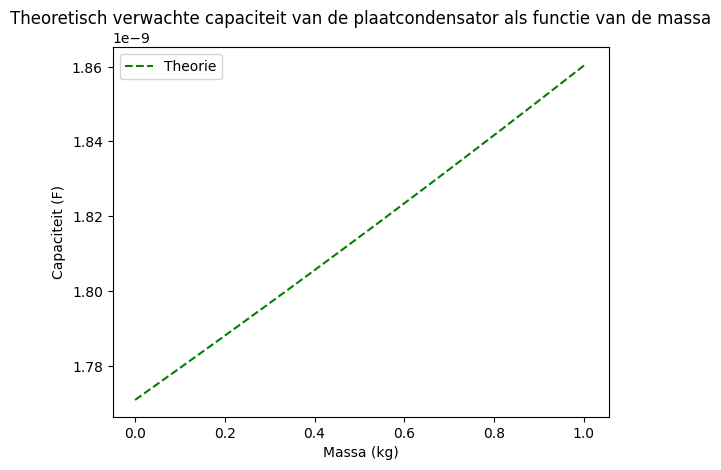

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

k= 1360742
epsilon0 = 8.854187817e-12
d_0 = 0.15e-3
g = 9.81
A = 0.01
pF = np.array([204, 236, 256, 303, 328, 360, 392, 482, 530, 578, 676, 685, 729, 756])*1e-12
m = np.array([0.001, 17.6, 30.5, 54.5, 69.0, 93.3, 115.3, 211.3, 292.5, 378.1, 454.0, 662.3, 799.2, 1005.1])*1e-3



def c_theorie(m,k):
    return epsilon0*A*3/(d_0 - m*g/k)


values, covariance = curve_fit(c_theorie, m, pF,maxfev=10000)

m2_test = np.logspace(np.log10(min(m)), np.log10(max(m)), 1000)

plt.plot(m2_test, c_theorie(m2_test, k), 'g--', label='Theorie')

plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (F)')
plt.legend()
plt.title('Theoretisch verwachte capaciteit van de plaatcondensator als functie van de massa')
plt.show()

#We gaan hier dus uit van een linear verband tussen de massa en de capaciteit.

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 50pF |251mV |
| gemiddelde capaciteit| 2475pF |6.5V |
| maximale capaciteit| 5000pF |7.3V |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
<img src="Actie1.png" alt="schets student 1" width="400"/>
<img src="Actie2.png" alt="schets student 1" width="400"/>

## Opdracht 7: Plot de kalibratiegrafiek.

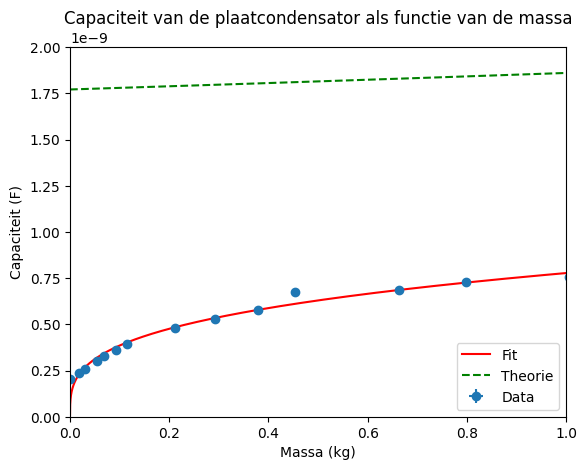

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

m_uncer = 0.05e-3
pF_uncer = 1e-11
k= 1360742
epsilon0 = 8.854187817e-12
d_0 = 0.15e-3
g = 9.81
A = 0.01
pF = np.array([204, 236, 256, 303, 328, 360, 392, 482, 530, 578, 676, 685, 729, 756])*1e-12
m = np.array([0.001, 17.6, 30.5, 54.5, 69.0, 93.3, 115.3, 211.3, 292.5, 378.1, 454.0, 662.3, 799.2, 1005.1])*1e-3
d = d_0 - m*g/k

def c_theorie(m,k):
    return epsilon0*A*3/(d_0 - m*g/k)

def func(x,a,b):
    return a*x**b

values, covariance = curve_fit(c_theorie, m, pF,maxfev=10000)
values, covariance = curve_fit(func, m, pF,maxfev=10000)

m_test = np.linspace(min(m), max(m), 10000)
m2_test = np.logspace(np.log10(min(m)), np.log10(max(m)), 1000)
c_test = func(m_test, *values)

plt.errorbar(m, pF, xerr=m_uncer, yerr=pF_uncer, fmt='o', label='Data')

plt.plot(m_test, c_test, 'r-', label='Fit')
plt.plot(m2_test, c_theorie(m2_test, k), 'g--', label='Theorie')

plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (F)')
plt.xlim(0, 1)
plt.ylim(0, 2e-9)
plt.legend()
plt.title('Capaciteit van de plaatcondensator als functie van de massa')
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1:
Vervanging van het papier door een Elastomeer of een veer.
Het nu gebruikte papier is redelijk stug waardoor het niet heel goed inveert en als het eenmaal ingeveerd is, veert het ook niet meer helemaal uit naar de orginele staat. Elastischere materialen zullen sneller en verder indeuken waardoor ze sneller de correcte waarde aangeven en een makkelijker en nauwkeurigafleesbare waarde zullen aangeven door een groter meetbaar verschil in de capaciteit.
* verbetering 2:
Een stevig en waterpas statief bouwen voor de capacitor platen zodat deze waterpas en recht boven elkaars staan. Dit zorgt voor minder onnauwkeurigheid door verschuiving van de platen ten opzichte van elkaar en door ongelijke verdeling van het gewicht over het oppervlakte.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
<img src="Actie1.png" alt="schets student 1" width="400"/>

In [5]:
# We hadden in het lokaal waar we in zaten geen toegang tot een elastomeer of voldoende veren van hetzelfde formaat, 
# verder hebben we nog getracht de capacitor te stabiliseren met houten plaatjes maar we hadden helaas niet meer de tijd om nog een meting uit te voeren.


## Opdracht 10: Vul hieronder de conclusie in.

De in dit project gemaakte weegschaal blijkt aan de van te voren gestelde doelen te voldoen, in een range van 0 tot 1 kg kan met redelijke nauwkeurigheid gemeten worden. Uit de kalibratiegrafiek blijkt dat de capaciteit bij toenemende massa snel toeneemt, maar naarmate de massa groter blijft worden steeds minder snel toeneemt. Dit komt doordat het steeds lastiger wordt om het papier samen te drukken doordat het grootste deel van het veervermogen er al uit is.
De verandering in de capaciteit blijkt verder groot genoeg te zijn om een gewicht met deze Arduino opstelling betrouwbaar te bepalen binnen de orde van grootte die vooraf beoogd werd. De sensor voldoet dus aan ons oorspronkelijke ontwerpdoel.

Er bleken wel een groot verschil te zitten tussen het theoretische model, wat we gebaseerd hadden op de formule van de vlakke plaatcondensator en de gemeten kalibratiedata. Het theoretische verband gaf ons een linear verband volgens de volgende formule:

$$ C_{\text{theorie}} = \frac{\varepsilon_0 \, \varepsilon_r \, A}{d_0 - \frac{m g}{k}} $$

Hiervoor is aangenomen dat de indrukking van het papier volgens de veerwet: $ F = kx $ verloopt.

Dit impliceert dat het papier zich gedraagt als een ideale veer mer veerconstante k, wat door zijn stugheid en toename van stijfheid bij indrukking practisch niet blijkt te kloppen. 
De relatie tussen het gewicht en de indrukking is dus niet linear, hierdoor wordt de afstand tussen de platen bij grotere massa's steeds minder snel keiner, waardoor de capaciteit dus ook minder snle zal toenemen.

Zoals eerder al genoemd, bij de eventuele verbeteringen van onze opstelling zal ook de niet perfecte parallelstand van de platen een zekere onzekerheid opleveren

Hoewel de gevonden formule op basis van de vlakke plaat formule niet geheel overheen lijkt te komen met de kalibratiegrafiek, hebben we wel een functiefit gevonden die goed met de gemeten data overeenkomt. 
Met behulp van deze functie kan met redelijke nauwkeurigheid een gewicht tussen de 0 en 1kg bepaald worden met behulp van onze opstelling. De sensor werkt dus en is geschikt voor het van te voren beoogde doel.


## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

In [6]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
epsilon0 = 8.854187817e-12 # F/m
def vlakkeplaat(epsilon0,epsilon_r, A, d):
    C = epsilon0*epsilon_r*A/d
    return C

#opstellen van het theoretische model van vlakkeplaat is een voorbeeld van leerdoel 1

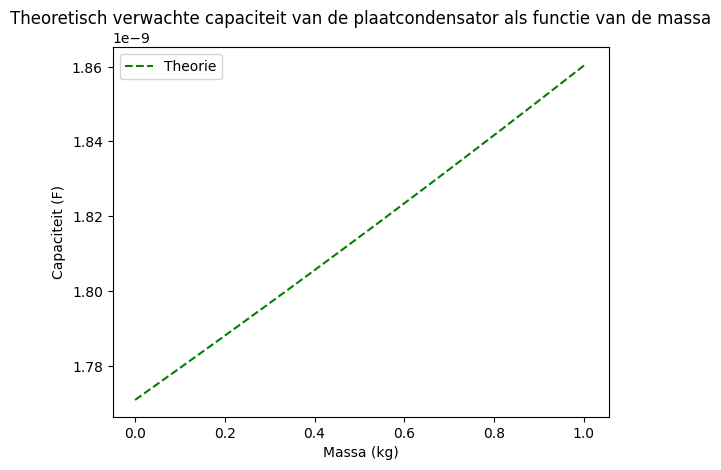

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

k= 1360742
epsilon0 = 8.854187817e-12
d_0 = 0.15e-3
g = 9.81
A = 0.01
pF = np.array([204, 236, 256, 303, 328, 360, 392, 482, 530, 578, 676, 685, 729, 756])*1e-12
m = np.array([0.001, 17.6, 30.5, 54.5, 69.0, 93.3, 115.3, 211.3, 292.5, 378.1, 454.0, 662.3, 799.2, 1005.1])*1e-3



def c_theorie(m,k):
    return epsilon0*A*3/(d_0 - m*g/k)


values, covariance = curve_fit(c_theorie, m, pF,maxfev=10000)

m2_test = np.logspace(np.log10(min(m)), np.log10(max(m)), 1000)

plt.plot(m2_test, c_theorie(m2_test, k), 'g--', label='Theorie')

plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (F)')
plt.legend()
plt.title('Theoretisch verwachte capaciteit van de plaatcondensator als functie van de massa')
plt.show()

#We gaan hier dus uit van een linear verband tussen de massa en de capaciteit.

# opstellen van de formule c_theorie toont wederom aan dat we dit leerdoel beheersen

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 50pF |251mV |
| gemiddelde capaciteit| 2475pF |6.5V |
| maximale capaciteit| 5000pF |7.3V |

In deze cel staan data gevonden door het analyseren van de condensator in een schakeling in LTSpice, daarmee toenen we aan dat we Kennis hebben van gedrag van elektrische componenten en meetopstellingen.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1:
Vervanging van het papier door een Elastomeer of een veer.
Het nu gebruikte papier is redelijk stug waardoor het niet heel goed inveert en als het eenmaal ingeveerd is, veert het ook niet meer helemaal uit naar de orginele staat. Elastischere materialen zullen sneller en verder indeuken waardoor ze sneller de correcte waarde aangeven en een makkelijker en nauwkeurigafleesbare waarde zullen aangeven door een groter meetbaar verschil in de capaciteit.
* verbetering 2:
Een stevig en waterpas statief bouwen voor de capacitor platen zodat deze waterpas en recht boven elkaars staan. Dit zorgt voor minder onnauwkeurigheid door verschuiving van de platen ten opzichte van elkaar en door ongelijke verdeling van het gewicht over het oppervlakte.


In deze cel laat de reflectie op de mechanische instabiliteit van onze opstelling zien dat we inzien dat deze effecten invloed hebben op de metingen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

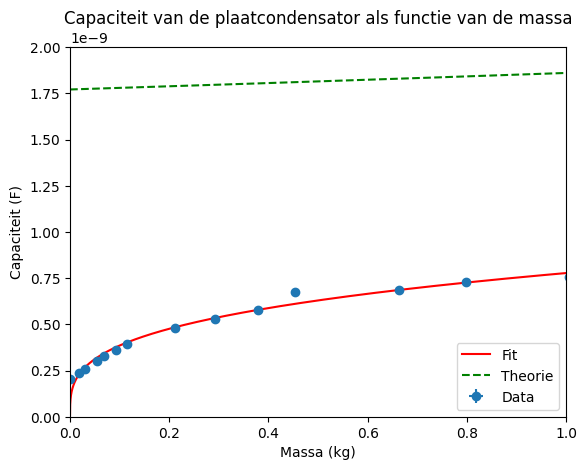

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

m_uncer = 0.05e-3
pF_uncer = 1e-11 #onzekerheid is 1e-11, want onze manier van meten was een gewicht erop leggen en dan wachten totdat de waarde stabiel was, dit is dus een schatting van de onzekerheid
k= 1360742
epsilon0 = 8.854187817e-12
d_0 = 0.15e-3
g = 9.81
A = 0.01
pF = np.array([204, 236, 256, 303, 328, 360, 392, 482, 530, 578, 676, 685, 729, 756])*1e-12
m = np.array([0.001, 17.6, 30.5, 54.5, 69.0, 93.3, 115.3, 211.3, 292.5, 378.1, 454.0, 662.3, 799.2, 1005.1])*1e-3
d = d_0 - m*g/k

def c_theorie(m,k):
    return epsilon0*A*3/(d_0 - m*g/k)

def func(x,a,b):
    return a*x**b

values, covariance = curve_fit(c_theorie, m, pF,maxfev=10000)
values, covariance = curve_fit(func, m, pF,maxfev=10000)

m_test = np.linspace(min(m), max(m), 10000)
m2_test = np.logspace(np.log10(min(m)), np.log10(max(m)), 1000)
c_test = func(m_test, *values)

plt.errorbar(m, pF, xerr=m_uncer, yerr=pF_uncer, fmt='o', label='Data')

plt.plot(m_test, c_test, 'r-', label='Fit')
plt.plot(m2_test, c_theorie(m2_test, k), 'g--', label='Theorie')

plt.xlabel('Massa (kg)')
plt.ylabel('Capaciteit (F)')
plt.xlim(0, 1)
plt.ylim(0, 2e-9)
plt.legend()
plt.title('Capaciteit van de plaatcondensator als functie van de massa')
plt.show()

# In deze cel wordt een kalibratiegrafiek opgesteld evenals errorbars geplot, dit is dus een cel waar leerdoel 3 toegepast wordt.

Opdracht 10: conclusie

De in dit project gemaakte weegschaal blijkt aan de van te voren gestelde doelen te voldoen, in een range van 0 tot 1 kg kan met redelijke nauwkeurigheid gemeten worden. Uit de kalibratiegrafiek blijkt dat de capaciteit bij toenemende massa snel toeneemt, maar naarmate de massa groter blijft worden steeds minder snel toeneemt. Dit komt doordat het steeds lastiger wordt om het papier samen te drukken doordat het grootste deel van het veervermogen er al uit is.
De verandering in de capaciteit blijkt verder groot genoeg te zijn om een gewicht met deze Arduino opstelling betrouwbaar te bepalen binnen de orde van grootte die vooraf beoogd werd. De sensor voldoet dus aan ons oorspronkelijke ontwerpdoel.

Er bleken wel een groot verschil te zitten tussen het theoretische model, wat we gebaseerd hadden op de formule van de vlakke plaatcondensator en de gemeten kalibratiedata. Het theoretische verband gaf ons een linear verband volgens de volgende formule:

$$ C_{\text{theorie}} = \frac{\varepsilon_0 \, \varepsilon_r \, A}{d_0 - \frac{m g}{k}} $$

Hiervoor is aangenomen dat de indrukking van het papier volgens de veerwet: $ F = kx $ verloopt.

Dit impliceert dat het papier zich gedraagt als een ideale veer mer veerconstante k, wat door zijn stugheid en toename van stijfheid bij indrukking practisch niet blijkt te kloppen. 
De relatie tussen het gewicht en de indrukking is dus niet linear, hierdoor wordt de afstand tussen de platen bij grotere massa's steeds minder snel keiner, waardoor de capaciteit dus ook minder snle zal toenemen.

Zoals eerder al genoemd, bij de eventuele verbeteringen van onze opstelling zal ook de niet perfecte parallelstand van de platen een zekere onzekerheid opleveren

Hoewel de gevonden formule op basis van de vlakke plaat formule niet geheel overheen lijkt te komen met de kalibratiegrafiek, hebben we wel een functiefit gevonden die goed met de gemeten data overeenkomt. 
Met behulp van deze functie kan met redelijke nauwkeurigheid een gewicht tussen de 0 en 1kg bepaald worden met behulp van onze opstelling. De sensor werkt dus en is geschikt voor het van te voren beoogde doel.
